# 📑 Bangla Hate Speech Detection Using Machine Learning

This notebook demonstrates a complete Machine Learning pipeline to detect and classify hate speech in the Bengali language. 

### **Steps included:**
1. **Environment Setup:** Importing essential Data Science and ML libraries.
2. **Data Loading:** Reading the Bengali hate speech dataset.
3. **Text Preprocessing:** Cleaning Bangla text using Regular Expressions (Regex).
4. **Feature Engineering:** Converting text into numerical data using **TF-IDF Vectorization**.
5. **Handling Imbalance:** Using **SMOTE** to balance the different categories of hate speech.
6. **Model Training:** Training **Linear Support Vector Machine (SVM)** and **Logistic Regression** models.
7. **Evaluation:** Comparing models using Accuracy, Confusion Matrices, and Classification Reports.

In [28]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================
# pandas: For data manipulation and analysis
import pandas as pd
# re: Regular expressions for text cleaning
import re
# matplotlib: For generating graphs and visualizations
import matplotlib.pyplot as plt

# sklearn: The standard library for Machine Learning in Python
# TfidfVectorizer: Converts text to numbers based on word frequency/importance
from sklearn.feature_extraction.text import TfidfVectorizer
# train_test_split: Splits data into Training set (80%) and Testing set (20%)
from sklearn.model_selection import train_test_split
# LinearSVC & LogisticRegression: The classification algorithms we are using
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
# Evaluation metrics to see how well our models perform
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# imblearn (SMOTE): To fix dataset imbalance by generating synthetic samples
from imblearn.over_sampling import SMOTE

In [29]:
# ==========================================================
# 2. LOAD DATASET
# ==========================================================
# We load the CSV file containing Bangla text and their respective hate labels
df = pd.read_csv("final_bengali_hate_speach_dataset.csv")

print("Dataset Shape:", df.shape) # Total rows and columns
print("Sample Data:")
print(df.head()) # Previewing the first 5 rows

Dataset Shape: (5698, 3)
Sample Data:
                                                text         label  target
0  বৌদির দুধ দেকে তো আমার ই চোখ ঠিক ছিলো না - পোল...      Personal       0
1  এই সরকার কে যারা নির্লজ্জের মত সাপোর্ট দিয়েছে ...     Political       1
2  পিলখানা হত্যাকান্ড বাংলাদেশের প্রতিরক্ষা ব্যবস...  Geopolitical       3
3  ভারতের অর্থনীতি নিয়ে আপনাদের ভাবতে হবে না। ভা...  Geopolitical       3
4            খানকির পুলা মালায়নদের মেরে সাফা করে ফেল      Personal       0


In [30]:
# ==========================================================
# 3. TEXT CLEANING (Preprocessing)
# ==========================================================
def clean_bangla_text(text):
    """
    This function removes special characters, symbols, and punctuation.
    It keeps only Bangla characters, English letters, and numbers.
    """
    text = str(text).lower()
    # Regex range [\u0980-\u09FF] specifically targets the Bangla Unicode block
    text = re.sub(r'[^a-zA-Z0-9\u0980-\u09FF\s]', '', text)
    return text

# Apply the cleaning function to the 'text' column
df['text'] = df['text'].apply(clean_bangla_text)
print("Text cleaning completed.")

Text cleaning completed.


In [31]:
# ==========================================================
# 4. TF-IDF FEATURE EXTRACTION
# ==========================================================
# Computers don't understand text; we must convert it to numbers.
# TF-IDF (Term Frequency-Inverse Document Frequency) gives weight to 
# words that are unique and meaningful in the dataset.
tfidf = TfidfVectorizer(
    max_features=20000, # Limit to the top 20,000 most important words
    ngram_range=(1,3),  # Look at single words, pairs, and triples (e.g., "hate", "very bad", "go to hell")
    min_df=2            # Ignore words that appear only once in the whole dataset
)

X = tfidf.fit_transform(df['text']) # Numerical features (Input)
y = df['label']                     # Hate categories (Target output)

In [32]:
# ==========================================================
# 5. SMOTE (Data Balancing)
# ==========================================================
# If one category (e.g., Political Hate) has many more samples than another,
# the model will be biased. SMOTE balances the classes by creating
# artificial data points for the minority classes.
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Data balancing (SMOTE) completed.")

Data balancing (SMOTE) completed.


In [33]:
# ==========================================================
# 6. TRAIN-TEST SPLIT
# ==========================================================
# We use 80% of the data to 'teach' the model (Training)
# We use 20% of the data to 'test' if it learned correctly (Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,    # 20% for testing
    random_state=42   # Ensures the split is the same every time we run it
)

In [34]:
# ==========================================================
# 7. MODEL training: Linear SVM
# ==========================================================
# Support Vector Machine (SVM) is excellent for text classification.
svm_model = LinearSVC(class_weight='balanced')
svm_model.fit(X_train, y_train) # Training phase

# Prediction phase
svm_pred = svm_model.predict(X_test)

print("\n===== SVM RESULTS =====")
print("Accuracy Score:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))


===== SVM RESULTS =====
Accuracy Score: 0.783675799086758

Classification Report:
              precision    recall  f1-score   support

Geopolitical       0.84      0.73      0.78       423
    Personal       0.74      0.67      0.70       433
   Political       0.72      0.89      0.79       445
   Religious       0.86      0.84      0.85       451

    accuracy                           0.78      1752
   macro avg       0.79      0.78      0.78      1752
weighted avg       0.79      0.78      0.78      1752



In [35]:
# ==========================================================
# 8. MODEL training: Logistic Regression
# ==========================================================
# Logistic Regression is a classic statistical model for classification.
lr_model = LogisticRegression(max_iter=500, class_weight='balanced')
lr_model.fit(X_train, y_train) # Training phase

# Prediction phase
lr_pred = lr_model.predict(X_test)

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print("Accuracy Score:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))


===== LOGISTIC REGRESSION RESULTS =====
Accuracy Score: 0.7488584474885844

Classification Report:
              precision    recall  f1-score   support

Geopolitical       0.83      0.68      0.74       423
    Personal       0.70      0.70      0.70       433
   Political       0.66      0.82      0.73       445
   Religious       0.84      0.79      0.81       451

    accuracy                           0.75      1752
   macro avg       0.76      0.75      0.75      1752
weighted avg       0.76      0.75      0.75      1752



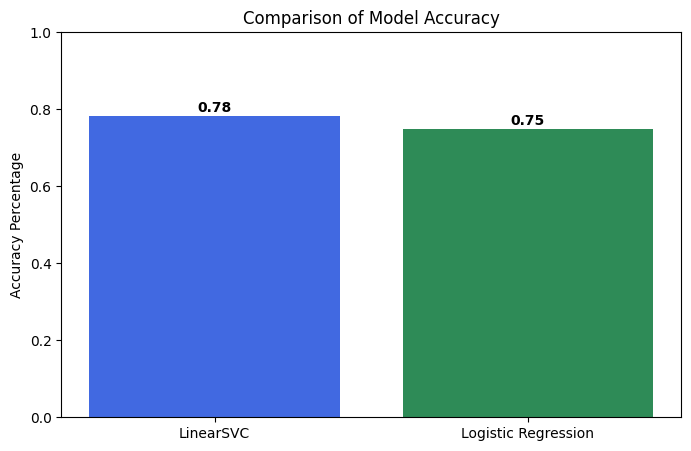

In [36]:
# ==========================================================
# 9. VISUALIZATION: Performance Comparison
# ==========================================================
models = ['LinearSVC', 'Logistic Regression']
accuracy = [accuracy_score(y_test, svm_pred), accuracy_score(y_test, lr_pred)]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracy, color=['royalblue', 'seagreen'])
plt.title("Comparison of Model Accuracy")
plt.ylabel("Accuracy Percentage")
plt.ylim(0, 1.0)
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

# --- CODE FOR COLAB DOWNLOAD ---
plt.savefig("accuracy_comparison.png", dpi=300, bbox_inches='tight')
try:
    from google.colab import files
    files.download("accuracy_comparison.png")
except ImportError:
    pass # Not in Colab
# -------------------------------

plt.show()

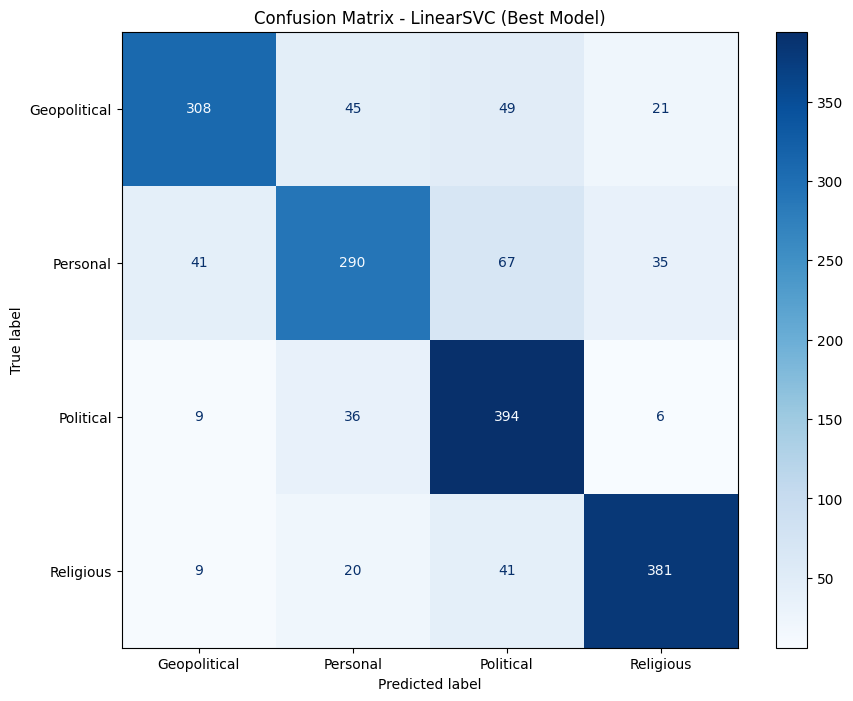

In [37]:
# ==========================================================
# 10. VISUALIZATION: Confusion Matrix (SVM)
# ==========================================================
# A Confusion Matrix shows exactly where the model is making mistakes
# (e.g., misclassifying Political hate as Personal hate).
cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix - LinearSVC (Best Model)")

# --- CODE FOR COLAB DOWNLOAD ---
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
try:
    from google.colab import files
    files.download("confusion_matrix.png")
except ImportError:
    pass # Not in Colab
# -------------------------------

plt.show()